In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

import tqdm as tqdm

In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 14,                          # Standard font size for scientific papers
    "axes.labelsize": 14,                     # Size of the x and y axis labels
    "xtick.labelsize": 12,                     # Size of the x-tick labels
    "ytick.labelsize": 12,                     # Size of the y-tick labels
    "legend.fontsize": 12,                     # Size of the legend text
    "figure.titlesize": 16                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
# =======================
# BASE COSMOLOGY: Planck 2015 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.041783
omega_b     = 0.022383
omega_cdm0  = 0.12011
tau_reio    = 0.0543
A_s         = 2.1005829616811546e-9
n_s         = 0.96605

base_params = {
    "theta_s_100": theta_s_100,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,
}

In [4]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set(base_params) 
lcdm.set({
    "output": "tCl,pCl,lCl,mPk",
    "l_max_scalars": 2500,
})
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")

cl_lcdm = lcdm.raw_cl(2500)
ll_lcdm = cl_lcdm['ell'][2:]
clTT_lcdm = cl_lcdm['tt'][2:]
clEE_lcdm = cl_lcdm['ee'][2:]
clTE_lcdm = cl_lcdm['te'][2:]


Redshift of matter-radiation equality in LCDM: 3405.82


In [5]:
### Constants

num_of_gigayears = 0.1 # REMOVE, Irrelevant in this formulation
tau_acc = num_of_gigayears*3600*24*365*1e9 # REMOVE, Irrelevant in this formulation
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e16
m_wdm = 1e16 # in accDM model it should be the same as mass of the DM particle before acceleration, but this implementation is more general and allows to set them independently
kappa = 10
a_t = 0.1

In [6]:
mass_values = 1e11, 1e13, 1e15, 1e17
eta_list = 10**11/np.array(mass_values)
print("eta values:", eta_list)

eta values: [1.e+00 1.e-02 1.e-04 1.e-06]


In [7]:
### Run CLASS ###

# Output dictionaries
AccCLASS = {}
bgAcc, pbAcc, clAcc = {}, {}, {}

mass_values = [1e11, 2e11, 5e11, 1e12]
eta_list = 10**11/np.array(mass_values)

k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])
ncdm_q_steps = 301
a_rec = 1/(1+1090)

for eta in tqdm.tqdm(eta_list):
    mass = 10**11/eta
    if (mass*(1+eta) > 1e19) or (mass > 1e19):
        print(f"Warning: energy of the WDM particle after acceleration is {mass*(1+eta):.2e} GeV, which is above the Planck scale.")
        break
    
    AccCLASS = Class()
    AccCLASS.set(base_params)
    AccCLASS.set({  
                    'output': 'tCl, pCl, lCl, mPk',
                    'l_max_scalars': 2500, 
                    'k_output_values': k_values_CLASS,  
                    'omega_cdm': omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1),          
                    # accDM params
                    'vary_Gamma_acc': 'yes',               # Use the more general formulation
                    'kappa_acc':      kappa,               # 
                    'a_t_acc':        a_t,                 # Scale factor at which the acceleration happens
                    'f_acc':          f_acc,               # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                    'eta_acc':        eta,                 # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\eta)
                    "tau_acc":        tau_acc,             # REMOVE, Irrelevant in this formulation, but set it to a large value to avoid issues with the code, since we are not using the decay formulation
                    "m_acc_in_GeV":   mass,               # accDM mass in GeV
                    "m_cdm_in_GeV":   mass,              # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
                    # ncdm params [0] is for the neutrinos, [1] is for the WDM component
                    "N_ncdm":                   1,                       # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM in the ncdm sector
                    "deg_ncdm":                 1,                  # 3 neutrino species and 1 degrees of freedom for the WDM component 
                    "m_ncdm":                   mass*1e9,    # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
                    "T_ncdm":                   1,            # Set the same temperature for the WDM component as for the neutrinos,
                    "N_ur":                     3.044,                 # Set the number of massless neutrino species to 0 since we are including them as ncdm species
                    "ncdm_quadrature_strategy": 4,                  # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)
                    "ncdm_N_momentum_bins" :    ncdm_q_steps,   # Set a higher number of momentum bins for the WDM component, maybe the same number as evolution steps? But that's 40000, so a lot. FOR SIMPSION THE NUBMER OF MOMENTUM BINS SHOULD BE ODD, CHECK THIS
                    # precision
                    'reionization_z_start_max': 80,      # Default is 50, 80 is the minimal value that works for the chosen eta values if we set tau_reio to Planck 2018 value, it just widens the bracket so that this doesn't cause issue with shooting for h
                    "ncdm_fluid_approximation": 3,
                    # "switch_on_eq_delta_p_acc": 'no', 
                    "switch_off_shear_acc": 'yes', 
                    # "ncdm_fluid_trigger_tau_over_tau_k": 25,
                    'evolver': 0,
                    'background_Nloga': 5000
                    })
    AccCLASS.compute()
    bgAcc[eta] = AccCLASS.get_background()
    pbAcc[eta] = AccCLASS.get_perturbations()
    clAcc[eta] = AccCLASS.raw_cl(2500)


100%|██████████| 4/4 [01:49<00:00, 27.26s/it]


In [14]:
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, p_acc = {}, {}
smooth_rho_acc, smooth_p_acc = {}, {}
rho_nu = {}
rho_tot, rho_crit = {}, {}
z_eq = {}

delta_cdm, delta_g, delta_b, delta_ur, delta_nu = {}, {}, {}, {}, {}
delta_dcdm, delta_acc, delta_dr = {}, {}, {}
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}

for eta in eta_list:
    # a, z, and H
    H[eta] = bgAcc[eta]['H [1/Mpc]']
    z[eta] = bgAcc[eta]['z']
    a[eta] = 1/(1+z[eta])
    
    # The usual components of the universe
    rho_g[eta] = bgAcc[eta]['(.)rho_g'] 
    rho_b[eta] = bgAcc[eta]['(.)rho_b']
    rho_cdm[eta] = bgAcc[eta]['(.)rho_cdm']
    rho_lambda[eta] = bgAcc[eta]['(.)rho_lambda']
    rho_ur[eta] = bgAcc[eta]['(.)rho_ur']
    # rho_nu[eta] = bgAcc[eta]['(.)rho_ncdm[0]']

    # Energy densities of the DCDM and WDM components and the pressure of the WDM component
    rho_dcdm[eta] = bgAcc[eta]['(.)rho_acc_cdm']
    rho_acc[eta] = bgAcc[eta]['(.)rho_ncdm[0]']
    p_acc[eta] = bgAcc[eta]['(.)p_ncdm[0]']

    # Total and critical energy densities
    rho_tot[eta] = bgAcc[eta]['(.)rho_tot']
    rho_crit[eta] = bgAcc[eta]['(.)rho_crit']
    
    z_eq[eta] = AccCLASS.get_current_derived_parameters(['z_eq'])

    for i in range(len(k_values)):
        scalar_data = pbAcc[eta]['scalar'][i]  # Scalar perturbations for selected k-values
        # print(scalar_data.keys())
        a[eta, k_values[i]] = scalar_data['a']
    
        # Extract perturbation quantities
        delta_cdm[eta, k_values[i]] = scalar_data['delta_cdm']
        delta_g[eta, k_values[i]] = scalar_data['delta_g']
        delta_b[eta, k_values[i]] = scalar_data['delta_b']
        delta_ur[eta, k_values[i]] = scalar_data['delta_ur']
        # delta_nu[eta, k_values[i]] = scalar_data['delta_ncdm[0]']
        
        delta_dcdm[eta, k_values[i]] = scalar_data['delta_dcdm']
        delta_acc[eta, k_values[i]] = scalar_data['delta_ncdm[0]']    
        ## POWER SPECTRUM
        
    ll[eta] = clAcc[eta]['ell'][2:]
    clTT[eta] = clAcc[eta]['tt'][2:]
    clEE[eta] = clAcc[eta]['ee'][2:]
    clTE[eta] = clAcc[eta]['te'][2:]
    clPP[eta] = clAcc[eta]['pp'][2:]

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_359333/3111304281.py:19: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Relativistic part of accDM for different values of $\eta$')


Plotting for eta = 1.0
3405.8156566445978
Plotting for eta = 0.5
3405.8156566445978
Plotting for eta = 0.2
3405.8156566445978
Plotting for eta = 0.1
3405.8156566445978


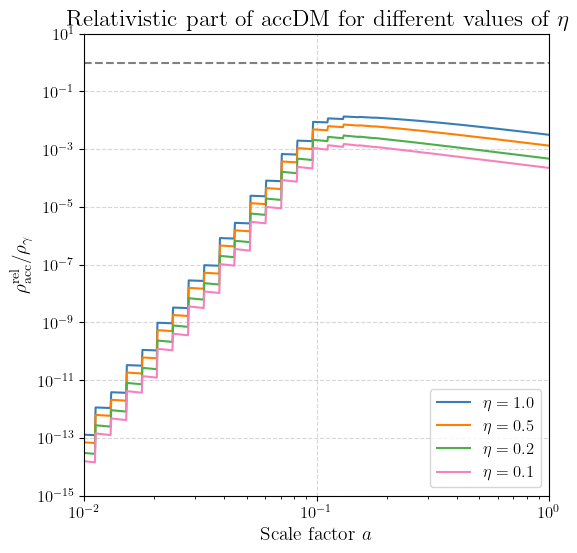

In [15]:
### Plot relativistic pressure of accDM for different values of eta
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

for eta in eta_list:
    print(f'Plotting for eta = {eta}')
    a_acc = a[eta]
    
    ax.plot(a_acc, 3*p_acc[eta]*a_acc**4/rho_cdm[eta][-1], label=r'$\eta = {}$'.format(eta), ls = '-', color=colors_colorblind[list(eta_list).index(eta)])
    
    ax.set_ylabel(r'$\rho_\mathrm{acc}^\mathrm{rel}/\rho_\gamma$')
    ax.set_xlabel(r'Scale factor $a$')
    print(z_eq[eta]['z_eq'])

ax.axhline(1, color='grey', linestyle='--')

ax.legend()
ax.set_title('Relativistic part of accDM for different values of $\eta$')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-15, 10)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)
# ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')

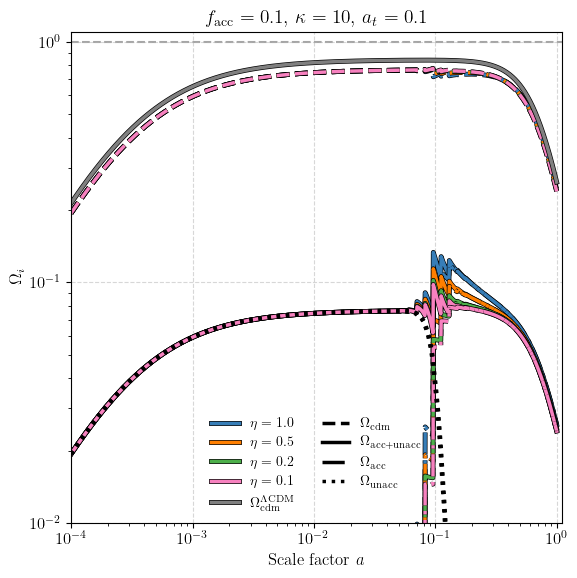

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

outline = [pe.withStroke(linewidth=3.5, foreground='black')]
line_w = 2.5

for idx, eta in enumerate(eta_list):
    a_acc = a[eta]
    c = colors_colorblind[idx % len(colors_colorblind)] # Safe indexing in case eta_list > colors
    
    # cdm = solid (-), acc = dotted (:), dcdm = dashed (--)
    ax.plot(a_acc, rho_cdm[eta]/rho_tot[eta], 
              linewidth=line_w, ls='--', path_effects=outline, color=c)
    ax.plot(a_acc, (rho_dcdm[eta]+rho_acc[eta])/rho_tot[eta], 
              linewidth=line_w, ls='-', path_effects=outline, color=c, label=rf'$\eta = {eta}$')
    ax.plot(a_acc, rho_acc[eta]/rho_tot[eta], 
              linewidth=line_w, ls='-.', path_effects=outline, color=c)
    
    Omega_dm_tot = rho_cdm[eta]/rho_tot[eta] + rho_dcdm[eta]/rho_tot[eta]
    Omega_dm_acc = Omega_dm_tot + rho_acc[eta]/rho_tot[eta]
    # print(f"Omega_dm (without acc) today for eta = {eta}: {Omega_dm_tot[-1]:.4f}")
    # print(f"Omega_dm (with acc) today for eta = {eta}: {Omega_dm_acc[-1]:.4f}")

ax.plot(a_acc, rho_dcdm[eta]/rho_tot[eta], 
        linewidth=line_w, ls=':', path_effects=outline, color='black')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'$\Omega_i$', fontsize=12)
ax.set_xlabel(r'Scale factor $a$', fontsize=12)

ax.set_ylim(1e-2, 1.1)
ax.set_xlim(1e-4, 1.1)

ax.axhline(1, color='grey', linestyle='--', zorder=0, alpha=0.7)

# Lambda CDM Reference Plot
ax.plot(a_lcdm, rho_cdm_lcdm/rho_tot_lcdm, label=r'$\Omega_{\mathrm{cdm}}^{\Lambda\mathrm{CDM}}$', 
          linewidth=line_w, ls='-', path_effects=outline, color='grey')

handles, labels = ax.get_legend_handles_labels()

style_handles = [
    Line2D([0], [0], color='black', lw=line_w, ls='--', label=r'$\Omega_{\mathrm{cdm}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls='-', label=r'$\Omega_{\mathrm{acc}+\mathrm{unacc}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls='-.', label=r'$\Omega_{\mathrm{acc}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls=':', label=r'$\Omega_{\mathrm{unacc}}$'), 
]

ax.legend(handles=handles + style_handles, loc='best', fontsize=10, frameon=False, ncol=2)

ax.grid(ls='--', alpha=0.5)

ax.set_title(rf'$f_{{\text{{acc}}}} = {f_acc}$, $\kappa = {kappa}$, $a_t = {a_t}$', fontsize=14)

plt.tight_layout()
plt.show()

w_acc today for eta = 1.0: 0.0103
w_acc today for eta = 0.5: 0.0044
w_acc today for eta = 0.2: 0.0015
w_acc today for eta = 0.1: 0.0007


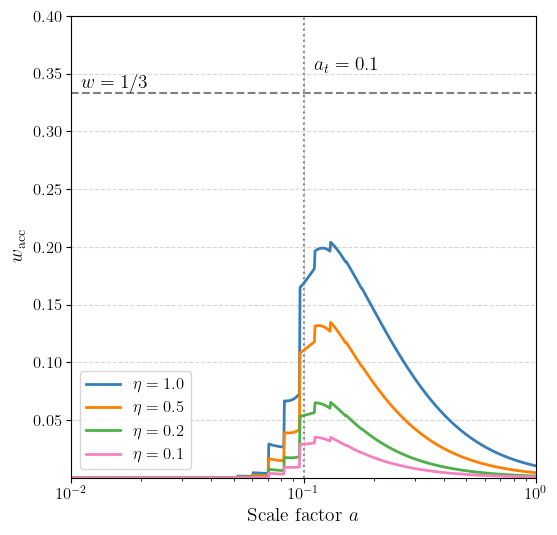

In [17]:
### Plot equation of state of accDM for different values of eta
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

colors = colors_colorblind

for eta in eta_list:
    a_acc = a[eta]
    
    w_acc_plot = p_acc[eta]/(rho_acc[eta]+rho_dcdm[eta])
    print(f"w_acc today for eta = {eta}: {w_acc_plot[-1]:.4f}")
    
    ax.semilogx(a_acc, w_acc_plot, label=r'$\eta = {}$'.format(eta), linewidth=2, ls = '-', color = colors_colorblind[list(eta_list).index(eta)])

    ax.set_ylabel(r'$w_\mathrm{acc}$')
    ax.set_xlabel(r'Scale factor $a$')

ax.axvline(a_t, color='gray', linestyle=':', zorder=-1)
ax.text(a_t+0.01, 0.35, r'$a_t={}$'.format(a_t), color='black', fontsize=14, zorder=-1, ha = 'left', va = 'bottom')

ax.axhline(1/3, color='grey', linestyle='--', zorder=-1)
ax.text(1.1e-2, 1/3, r'$w=1/3$', color='black', fontsize=14, zorder=-1, ha = 'left', va = 'bottom')

ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, 0.4)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)

Ratio at z=0:  0.9739701254007869
Ratio at z=0:  0.987284318808521
Ratio at z=0:  0.9946123072881516
Ratio at z=0:  0.9969027508712001


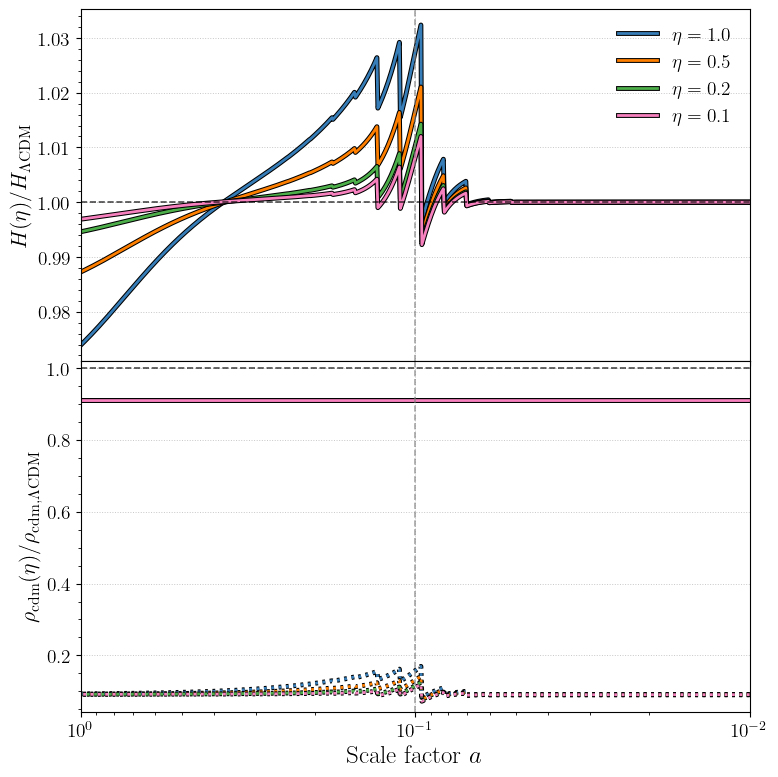

In [18]:
# Set up figure
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Interpolation functions
interp_H_lcdm = interp1d(a_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_rho_cdm_lcdm = interp1d(a_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

colors = colors_colorblind

# Loop over eta values
for i, eta in enumerate(eta_list):
    z_mon = z[eta]
    a_mon = a[eta]
    H_mon = H[eta]
    rho_cdm_mon = rho_cdm[eta]
    rho_acc_mon = rho_acc[eta]
    rho_dcdm_mon = rho_dcdm[eta]

    # Interpolated LCDM quantities onto a[eta] grid
    H_lcdm_interp = interp_H_lcdm(a_mon)
    rho_cdm_lcdm_interp = interp_rho_cdm_lcdm(a_mon)

    color = colors[i]
    
    # Plot 1: H / H_lcdm
    axs[0].semilogx(a_mon, H_mon / H_lcdm_interp, 
                    linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                    label=rf'$\eta={eta}$', color=color)

    print('Ratio at z=0: ', H_mon[-1]/H_lcdm_interp[-1])
    axs[0].axvline(x=1/(1+z_eq[eta]['z_eq']), linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # a_eq

    # Plot 2: rho_cdm / rho_cdm_lcdm
    axs[1].semilogx(a_mon, rho_cdm_mon / rho_cdm_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
    axs[1].semilogx(a_mon, (rho_dcdm_mon+rho_acc_mon) / rho_cdm_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color, ls=':')

    axs[1].set_ylim(None, 1.02)
    axs[1].axvline(x=1/(1+z_eq[eta]['z_eq']), linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # a_eq

    
# Common plot settings
titles = [
    r'$H(\eta)/H_{\Lambda\mathrm{CDM}}$',
    r'$\rho_{\mathrm{cdm}}(\eta)/\rho_{\mathrm{cdm},\Lambda\mathrm{CDM}}$',
]

for i, ax in enumerate(axs):
    ax.set_ylabel(titles[i], fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axvline(x=a_t, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)  # a_t line
    ax.set_xlim(1, 1e-2)
    if i == 0:
        ax.legend(fontsize=14, loc='upper right', frameon=False)

# X-axis label only on bottom plot
axs[-1].set_xlabel(r'Scale factor $a$', fontsize=18)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)

plt.show()

# Save the figure
fig.savefig('monopole_background.pdf', dpi=300, bbox_inches='tight')

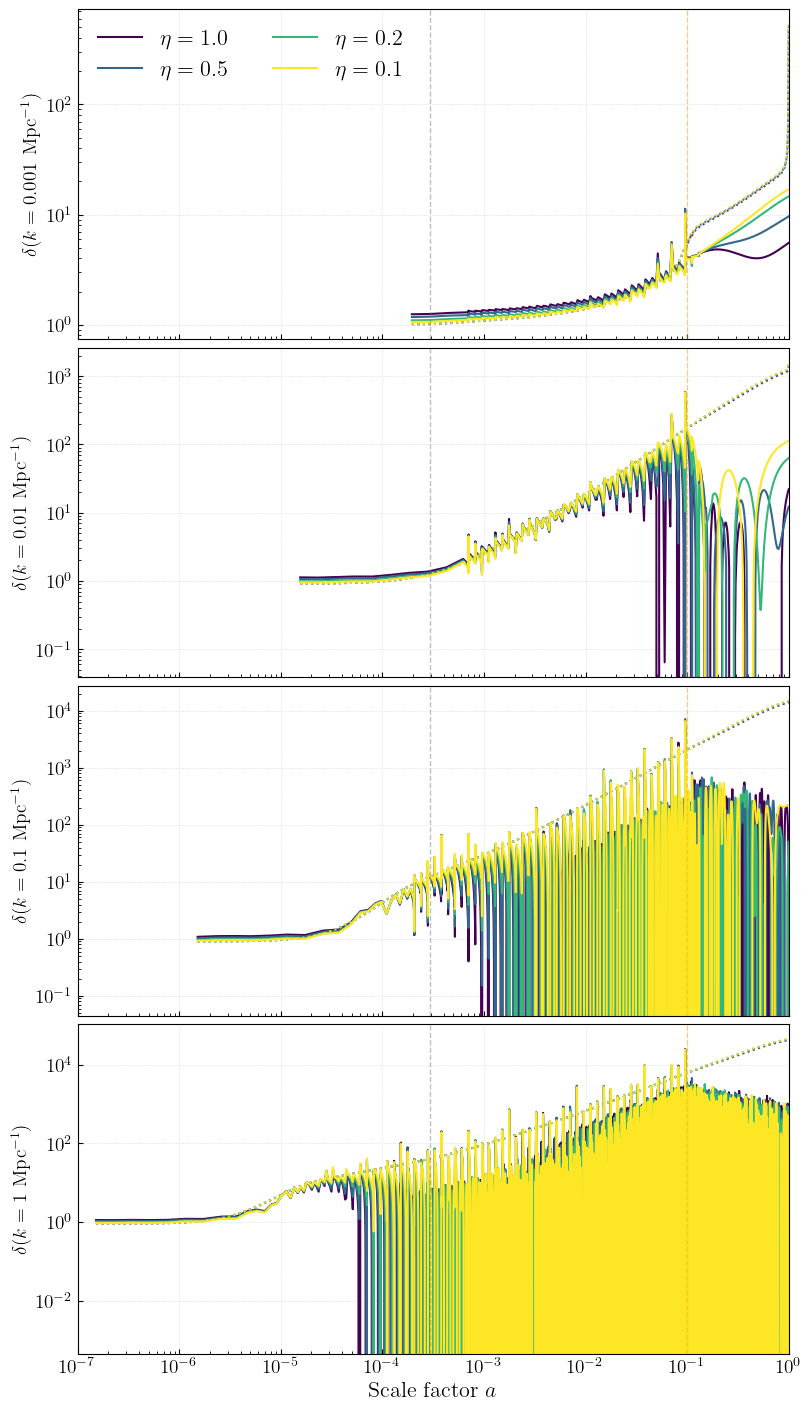

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Best practice: Choose a high-quality color cycle
plt.style.use('tableau-colorblind10') # Good for accessibility

fig, axs = plt.subplots(len(k_values), 1, figsize=(8, 3.5*len(k_values)), 
                        sharex=True, constrained_layout=True)

# Define a color map for eta_list to ensure consistency [cite: 462, 464]
colors = plt.cm.viridis(np.linspace(0, 1, len(eta_list)))

for i, k in enumerate(k_values):
    for j, eta in enumerate(eta_list):
        a_mon = a[eta, k]
        axs[i].plot(a_mon, -delta_acc[eta, k], color=colors[j], 
                    ls='-', label=rf'$\eta={eta}$')
        axs[i].plot(a_mon, -delta_dcdm[eta, k], color=colors[j], 
                    ls=':', alpha=0.8)

    # Specific ornaments for scientific context [cite: 831, 832]
    a_eq = 1/(1 + z_eq[eta]['z_eq'])
    axs[i].axvline(x=a_eq, ls='--', lw=1, color='gray', alpha=0.5)
    axs[i].axvline(x=a_t, ls='--', lw=1, color='orange', alpha=0.5)
    
    # Labeling and Scales [cite: 2342, 2347]
    axs[i].set_xscale('log')
    axs[i].set_xlim(1e-7, 1)
    axs[i].set_yscale('log')
    axs[i].set_ylabel(rf'$\delta(k={k}$ Mpc$^{{-1}}$)', fontsize=14)
    
    # Grid and Ticks refinement [cite: 661, 738]
    axs[i].grid(True, which='major', ls=':', lw=0.5, alpha=0.6)
    axs[i].tick_params(direction='in', which='both', labelsize=14)

    # Only one legend for the whole column [cite: 836, 851]
    if i == 0:
        axs[i].legend(fontsize=16, loc='upper left', frameon=False, ncol=2)

axs[-1].set_xlabel(r'Scale factor $a$', fontsize=16)

# Save with publication-ready resolution [cite: 1784, 1800]
# plt.savefig("perturbations.pdf", dpi=600)
plt.show()

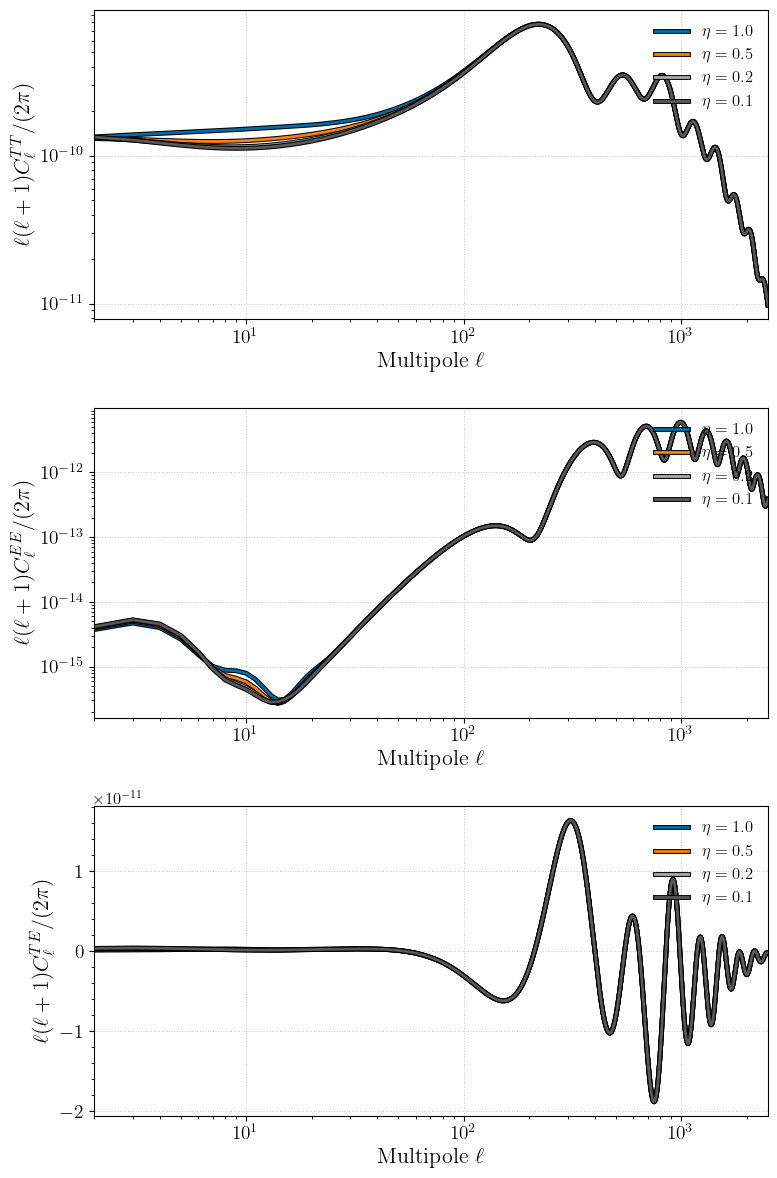

In [20]:
### PLot CMB power spectra for different values of eta
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

for i, (cl, label) in enumerate(zip([clTT, clEE, clTE], ['TT', 'EE', 'TE'])):
    for eta in eta_list:
        axs[i].plot(ll[eta], ll[eta]*(1+ll[eta])*cl[eta]/(2*np.pi), label=rf'$\eta={eta}$', color='C{}'.format(list(eta_list).index(eta)), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
    
    axs[i].set_xscale('log')
    axs[i].set_xlim(2, 2500)    
    axs[i].set_yscale('log') if label != 'TE' else axs[i].set_yscale('linear')
    axs[i].set_xlabel(r'Multipole $\ell$', fontsize=16)
    axs[i].set_ylabel(rf'$\ell(\ell+1)C_\ell^{{{label}}}/(2\pi)$', fontsize=16)
    axs[i].grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    axs[i].minorticks_on()
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].legend(fontsize=12, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

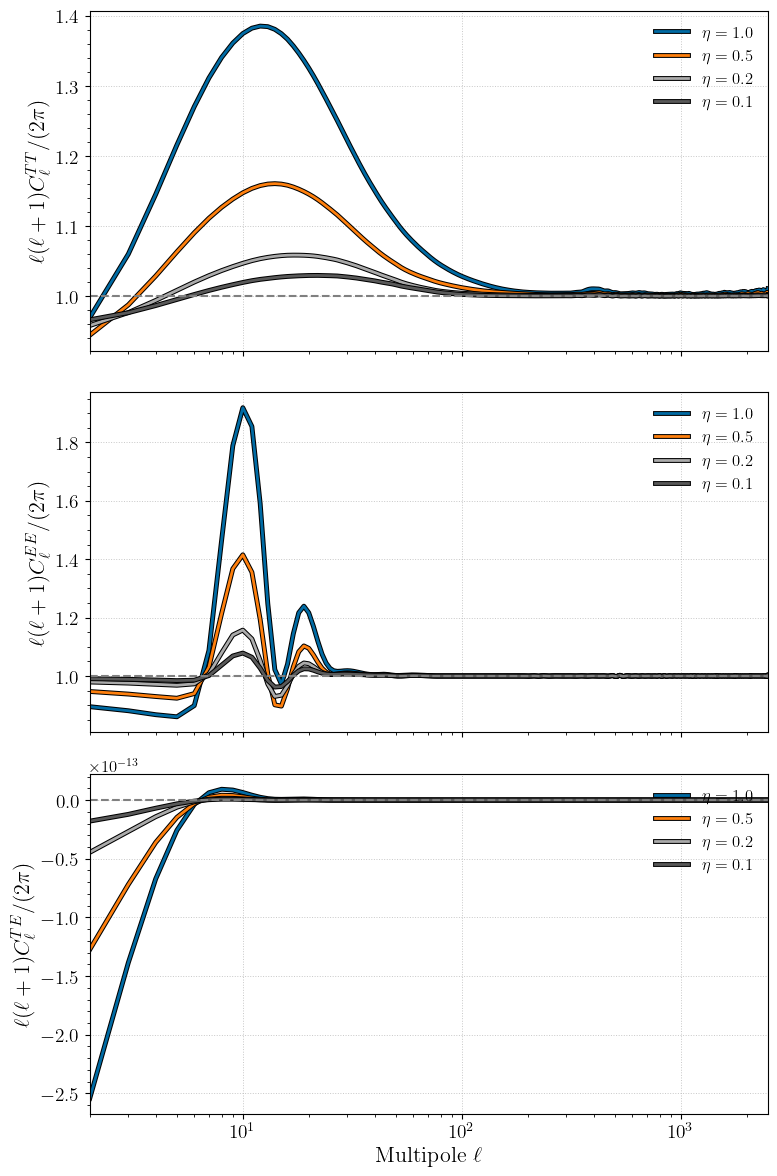

In [21]:
### PLot CMB power spectra for different values of eta
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex = True)

for i, (cl, label) in enumerate(zip([clTT, clEE, clTE], ['TT', 'EE', 'TE'])):
    for eta in eta_list:
        if cl is clTE:
            cl_lcdm = clTE_lcdm
        elif cl is clTT:
            cl_lcdm = clTT_lcdm
        elif cl is clEE:
            cl_lcdm = clEE_lcdm
        
        if cl is clTE:
            axs[i].plot(ll[eta], cl[eta]-cl_lcdm, label=rf'$\eta={eta}$', color='C{}'.format(list(eta_list).index(eta)), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')]) 
        else:
            axs[i].plot(ll[eta], cl[eta]/cl_lcdm, label=rf'$\eta={eta}$', color='C{}'.format(list(eta_list).index(eta)), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
    
    if cl is clTE:
        axs[i].axhline(0, color='grey', linestyle='--')
        axs[i].set_yscale('linear')
    else:
        axs[i].axhline(1, color='grey', linestyle='--')
        axs[i].set_yscale('linear')
    
    axs[i].set_xscale('log')
    axs[i].set_xlim(2, 2500)    
    axs[i].set_ylabel(rf'$\ell(\ell+1)C_\ell^{{{label}}}/(2\pi)$', fontsize=16)
    axs[i].grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    axs[i].minorticks_on()
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].legend(fontsize=12, loc='upper right', frameon=False)
    
axs[2].set_xlabel(r'Multipole $\ell$', fontsize=16)
plt.tight_layout()
plt.show()